In [779]:
# import Packages
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from tavily import TavilyClient
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.tools import tool
from tavily import TavilyClient
from dotenv import load_dotenv
from pprint import pprint
import os

In [780]:
# Get Env Vars
load_dotenv()
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [781]:
tavily_search = TavilyClient(api_key=TAVILY_API_KEY)

In [782]:
# Agent State
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: list[str]
    revision_number: int
    max_revisions: int

In [783]:
# LLM Model As Mind Of Agent
from langchain_groq import ChatGroq
groq_model = ChatGroq(model="llama-3.1-8b-instant", api_key=GROQ_API_KEY, temperature=0)

In [784]:
# Define Prompts for Each Agents
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections."""

WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}"""
RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""


REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""

In [785]:
print(groq_model)

metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}} profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True} client=<groq.resources.chat.completions.Completions object at 0x7fa3e2ed23c0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7fa3e2ed0d10> model_name='llama-3.1-8b-instant' temperature=1e-08 model_kwargs={} groq_api_key=SecretStr('**********')


In [786]:
# Method of Binding Tools - Langraph
@tool
def getEmployeeName(name: str):
    """
        This Function For Getting The Employee Name and Salary
    """
    return {
        "name": name,
        "salary": 3003
    }

# How to Deal With LLM With invoke Function and Bind Tools
messages = [SystemMessage("your are helpfull assistance that get employeee Salary based on tools only else return I don't know"),
        HumanMessage(content="what salary for ahmed ?")]

# Give LLm wich tool to use
llm_with_tools = groq_model.bind_tools([getEmployeeName])
# Send LLM message and get response
response = llm_with_tools.invoke(messages)  
pprint(response.tool_calls)
# NOTE: this does not execute tool. just for let LLM know about tool
# If we want our LLM execute tool --> we can use 

[{'args': {'name': 'ahmed'},
  'id': '5pnwtm0a9',
  'name': 'getEmployeeName',
  'type': 'tool_call'}]


In [787]:
# Method of Bing Tools and Execute - Using Langchain
from langchain.agents import create_agent

prompt = "give me Salary for Ahmed ?"
tools = [getEmployeeName]
messages = [HumanMessage(content="what salary for ahmed ?")]

# create agent
agent = create_agent(
    model=groq_model,
    system_prompt="you are helpfull assistant. give answer based just on tools. else return i do not know",
    tools=[getEmployeeName],
    # debug=True,
)
resp = agent.invoke(input={"messages": messages})
print(resp["messages"][-1].content)

The salary for Ahmed is 3003.


In [788]:
# We are here
# https://learn.deeplearning.ai/courses/ai-agents-in-langgraph/lesson/m0x4m/essay-writer

In [789]:
# Create Plan Agent
def plan_node(state: AgentState):
    print("PLANING ...")
    messages = [
        SystemMessage(PLAN_PROMPT),
        HumanMessage(content=state["task"] or [])
    ]
    response = groq_model.invoke(messages)
    return {"plan": response.content}

In [790]:
from pydantic import BaseModel
# BaseModel for define data structure
class Queries(BaseModel):
    queries: List[str]

In [791]:
# Create Research Agent
def research_node(state: AgentState):
    print("RESEARCH ...")
    messages = [
        SystemMessage(RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state["task"])
    ]
    # Structure LLM output with langchain
    '''
        - I tell LLM do not answer normally. we tell LLM to return a list of queries
        - Queries(
            queries=[
                "Benefits of electric vehicles",
                "Environmental impact of EV batteries",
                "Electric vehicles carbon emissions compared to gasoline cars"
            ]
        )
    '''
    queries = groq_model.with_structured_output(Queries).invoke(messages)
    content = state["content"] or []
    for q in queries.queries:
        response = tavily_search.search(q, max_results=2)
        for r in response["results"]:
            content.append(r["content"])
    return {"content": content}

In [792]:
# Generation Node
def generation_node(state: AgentState):
    print("GENERATION ...")
    content = "\n\n".join(state["content"] or [])
    messages = [SystemMessage(WRITER_PROMPT.format(content=content)), HumanMessage(content=f"{state["task"]} \n \n Here is my Plan {state["plan"]}")]
    response = groq_model.invoke(messages)
    return {
        "draft": response.content,
        "revision_number": state.get("revision_number", 1) + 1
    }

In [793]:
# Reflection Node
def reflection_node(state: AgentState):
    print("REFLECTION ...")
    messages = [
        SystemMessage(content=REFLECTION_PROMPT), 
        HumanMessage(content=state['draft'])
    ]
    response = groq_model.invoke(messages)
    return {"critique": response.content}

In [794]:
response = tavily_search.search(query="hello world", max_results=2)
print(response["results"][-1]["content"])

A "Hello, world" program is usually a simple computer program that outputs a message similar to "Hello, world". The text may be printed out or displayed on a screen (often a console). A small piece of code in most general-purpose programming languages, this program is used to illustrate a language's basic syntax "Syntax (programming languages)"). Such a program is often the first written by a student of a new programming language, but it can also be used as a sanity check to ensure that the [...] "Time to hello world" (TTHW) is the time it takes to author a "Hello, world" program in a given programming language. This is one measure of a programming language's ease of use. Since the program is meant as an introduction for people unfamiliar with the language, a more complex "Hello, world" program may indicate that the programming language is less approachable. For instance, the first publicly known "Hello, world" program in Malbolge (which actually output "HEllO WORld") took two years to

In [795]:
def research_critique_node(state: AgentState):
    print("RESEARCH CRITIC ....")
    queries = groq_model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily_search.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [796]:
# Define The Conditional Edges
def should_continue(state: AgentState):
    print("Should Continue ...")
    print("revision_number = ", state['revision_number'])
    print("max_revisions = ", state['max_revisions'])
    if state['revision_number'] > state["max_revisions"]:
        return "END"
    return "reflect"

In [797]:
workflow = StateGraph(AgentState)

In [798]:
workflow.add_node("planner", plan_node)
workflow.add_node("research_plan", research_node)
workflow.add_node("generate", generation_node)
workflow.add_node("reflect", reflection_node)
workflow.add_node("research_critique", research_critique_node)

In [799]:
# Add Edges
workflow.add_edge("planner", "research_plan")
workflow.add_edge("research_plan", "generate")
workflow.add_edge("reflect", "research_critique")
workflow.add_edge("research_critique", "generate")

In [800]:
workflow.set_entry_point("planner") 

In [801]:
workflow.add_conditional_edges("generate", should_continue,
    {
        "END": END,
        "reflect": "reflect"
    }
)

In [802]:
# Execute Graph
graph = workflow.compile()

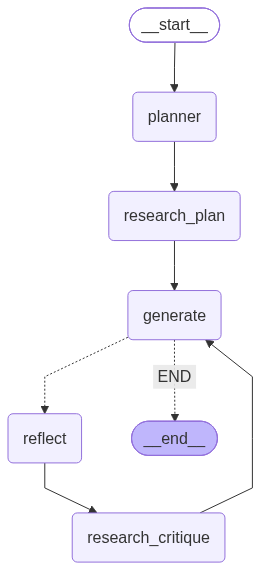

In [803]:
from IPython.display import Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Start Asking
thread = {"configurable": {"thread_id": "1"}}
result = ""
for s in graph.stream({
        "task": "why morroco is so poor",
        "max_revisions": 1,
        "revision_number": 1,
        "content": [""],
        "critique": "",
        "draft": "",
        "plan": ""
    }, thread):
    if (s.get("generate") is not None):
        result = s.get("generate")
    print(s)

PLANING ...
{'planner': {'plan': "Here's a high-level outline for an essay on why Morocco is so poor:\n\n**I. Introduction**\n\n* Brief overview of Morocco's economic situation\n* Thesis statement: Despite its rich natural resources and strategic location, Morocco remains one of the poorest countries in the Middle East and North Africa, due to a combination of historical, economic, and social factors.\n\n**II. Historical Factors**\n\n* Colonization by France and Spain (1912-1956)\n* Legacy of colonialism: exploitation of resources, suppression of local industries, and imposition of foreign institutions\n* Impact on Morocco's economic development and infrastructure\n* Notes: This section should provide a brief history of Morocco's colonization and its effects on the country's economy.\n\n**III. Economic Factors**\n\n* Dependence on agriculture and remittances from migrant workers\n* Limited industrialization and manufacturing sector\n* High unemployment and underemployment rates\n* Corr

In [813]:
from IPython.display import Markdown
display(Markdown(result["draft"]))

Here is a 5-paragraph essay based on the provided outline:

Morocco, a country located in the northwest corner of Africa, is often considered one of the poorest countries in the Middle East and North Africa. Despite its rich natural resources, including phosphates, iron ore, and fish, and its strategic location, Morocco struggles to provide a decent standard of living for its citizens. The country's economic situation is a complex issue, influenced by a combination of historical, economic, and social factors. This essay will examine the historical, economic, and social factors that contribute to Morocco's poverty, and discuss the government's efforts to address these challenges.

One of the primary historical factors that have contributed to Morocco's poverty is its colonization by France and Spain from 1912 to 1956. During this period, Morocco's natural resources were exploited, and local industries were suppressed in favor of foreign institutions. This legacy of colonialism has had a lasting impact on Morocco's economic development and infrastructure. The country's economy remains heavily dependent on agriculture and remittances from migrant workers, which are vulnerable to fluctuations in global markets. Additionally, the country's industrial sector is underdeveloped, and corruption and mismanagement of public resources are widespread.

Economic factors also play a significant role in Morocco's poverty. The country's high unemployment and underemployment rates, particularly among youth, are a major concern. According to the World Bank, the unemployment rate in Morocco was 13% in 2023, with higher rates among youth (35.8%) and women (18.3%). The country's limited access to education and healthcare also contributes to poverty, as many citizens lack the skills and knowledge necessary to participate in the economy. Furthermore, the country's cultural and social barriers to economic development, such as the preference for traditional industries and the lack of social mobility, also hinder economic growth.

Social factors also play a significant role in Morocco's poverty. The country's low levels of education and human capital are a major concern, as many citizens lack the skills and knowledge necessary to participate in the economy. According to the World Bank, 6.4% of the population in Morocco lives in multidimensional poverty, with an additional 10.9% classified as vulnerable to multidimensional poverty. The country's limited access to healthcare and social services also contributes to poverty, as many citizens lack access to basic services such as healthcare and education. Furthermore, the country's high poverty rates and income inequality are a major concern, as many citizens struggle to make ends meet.

In conclusion, Morocco's poverty is a complex issue, influenced by a combination of historical, economic, and social factors. The country's legacy of colonialism, dependence on agriculture and remittances, limited industrialization and manufacturing sector, high unemployment and underemployment rates, corruption and mismanagement of public resources, low levels of education and human capital, limited access to healthcare and social services, and high poverty rates and income inequality all contribute to its poverty. To address these challenges, the government must implement policies and reforms that promote economic growth, reduce poverty and inequality, and improve access to education and healthcare. This may include investing in education and healthcare, promoting industrialization and manufacturing, and reducing corruption and mismanagement of public resources.